<a href="https://colab.research.google.com/github/daoujunsung/Daou-FITs-3-YangJunsung/blob/%EC%8B%A4%EC%8A%B5/%5B%EC%8B%A4%EC%8A%B5%5D%20%5BCS%5D%20250109-%EC%8B%A4%EC%8A%B5%EA%B3%BC%EC%A0%9C24%2C25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 실습과제 24번

import pandas as pd
import numpy as np

# 랜덤 데이터 생성
np.random.seed(42)

# 고객 수
n = 1000

# 고객 특성 생성
data = {
    'customer_id': np.arange(1, n + 1),
    'age': np.random.randint(18, 70, size = n), # 18세에서 70세 사이의 나이
    'tenure': np.random.randint(1, 10, size=n), # 가입 기간(1년에서 10년 사이)
    'balance': np.random.uniform(0, 25000, size=n), # 잔액(0에서 25000 사이)
    'num_products': np.random.randint(1, 4, size=n), # 사용 중인 제품 수(1개에서 3개 사이)
    'has_credit_card': np.random.choice([0,1], size=n), # 신용카드 보유 여부
    'is_active_member': np.random.choice([0,1], size=n), # 활동 회원 여부
    'estimated_salary': np.random.uniform(30000, 150000, size=n), # 예상 연봉
    'churn': np.random.choice([0,1], size=n, p=[0.8, 0.2]) # 고객 이탈 여부 (20% 이탈)
}

# 데이터프레임 생성
df = pd.DataFrame(data)

# csv 파일로 저장
df.to_csv('customer_churn.csv', index=False)

# 데이터 확인
print(df.head())

   customer_id  age  tenure       balance  num_products  has_credit_card  \
0            1   56       3   6151.741470             1                1   
1            2   69       3  11917.386876             1                0   
2            3   46       9   9859.133095             1                0   
3            4   32       7  13735.355961             1                1   
4            5   60       5  18671.892903             1                1   

   is_active_member  estimated_salary  churn  
0                 0      51227.634099      0  
1                 1     148480.339030      0  
2                 0      83292.426829      0  
3                 1      93824.611981      0  
4                 0     134834.223448      0  


In [9]:
# 실습과제 25

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드
data = pd.read_csv('customer_churn.csv')

# 데이터 확인
print(data.head())

# 결측값 확인
print(data.isnull().sum())

   customer_id  age  tenure       balance  num_products  has_credit_card  \
0            1   56       3   6151.741470             1                1   
1            2   69       3  11917.386876             1                0   
2            3   46       9   9859.133095             1                0   
3            4   32       7  13735.355961             1                1   
4            5   60       5  18671.892903             1                1   

   is_active_member  estimated_salary  churn  
0                 0      51227.634099      0  
1                 1     148480.339030      0  
2                 0      83292.426829      0  
3                 1      93824.611981      0  
4                 0     134834.223448      0  
customer_id         0
age                 0
tenure              0
balance             0
num_products        0
has_credit_card     0
is_active_member    0
estimated_salary    0
churn               0
dtype: int64


In [10]:
# 특징 및 라벨 분리
X = data.drop('churn', axis = 1) # 예측할 변수 제외
y = data['churn'] # 예측할 변수 (이탈 여부)

# 범주형 변수 처리 (필요한 경우)
X = pd.get_dummies(X, drop_first=True)

# 데이터 분할 (훈련용, 테스트용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 표준화
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

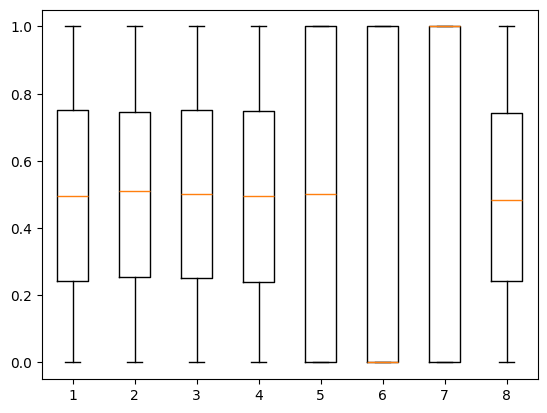

In [11]:
plt.boxplot(X_train)
plt.show()